In [14]:
config = []
with open('../graphMyself/Neo4j.config.txt', 'r') as configFile:
    for line in configFile.readlines():
        line = line.replace('\n', '')
        if line.startswith('NEO4J'):
            config.append(line.split('=')[1])

[url, username, password] = config

In [15]:
from py2neo import Graph
graph = Graph(url, auth=(username, password))

In [37]:
node_count = graph.nodes.match().count()
print("图中的节点数量为:", node_count)

图中的节点数量为: 5747


In [38]:
relation_count = graph.relationships.match().count()
print("图中的关系数量为:", relation_count)

图中的关系数量为: 23728


In [39]:
from collections import Counter

node_labels = [node.labels for node in graph.nodes.match()]
flattened_labels = [label for sublist in node_labels for label in sublist]
label_count = Counter(flattened_labels)
print("节点标签分布情况:")
for label, count in label_count.items():
    print(f"{label}: {count}")

节点标签分布情况:
Hospital: 3
Provider: 4
Nurse: 574
Patient: 2523
Area: 63
Order: 2580


In [6]:
results = graph.run('MATCH ()-[r]->() RETURN distinct type(r)')
print("关系类型分布情况:")
for res in results:
    relationType = res['type(r)']
    count = graph.run(f'MATCH ()-[r:{relationType}]->() RETURN count(r)').data()[0]['count(r)']
    print(f'{relationType}: {count}')

关系类型分布情况:
合作: 10
竞争: 12
雇佣: 574
受雇: 574
常驻: 574
服务: 2557
接取: 2580
负责: 1441
被服务: 2557
位于: 10269
创建: 2580


In [7]:
import random
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [10]:
results = graph.run('MATCH (n) RETURN COUNT{(n)-[]->()} AS outDegree').data()
outDegrees = [res['outDegree'] for res in results]
outDegrees = random.sample(outDegrees, len(outDegrees))

results = graph.run('MATCH (n) RETURN COUNT{()-[]->(n)} AS inDegree').data()
inDegrees = [res['inDegree'] for res in results]
inDegrees = random.sample(inDegrees, len(inDegrees))

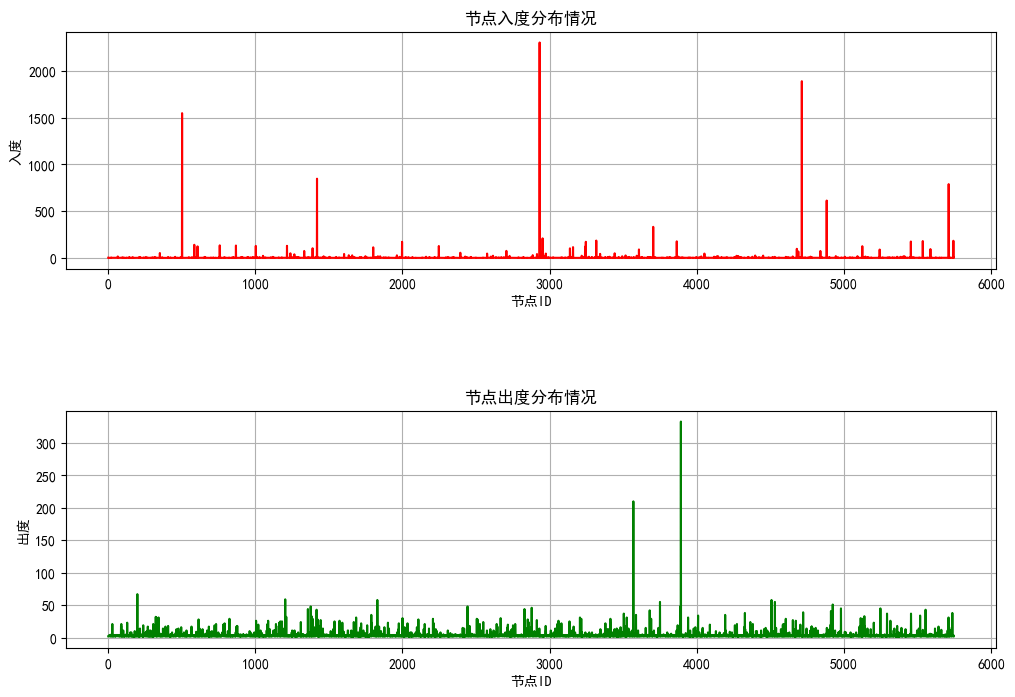

In [11]:
fig = plt.figure(figsize=(12,8), dpi=100)  # otherwise plots are really small in Jupyter Notebook
fig.subplots_adjust(hspace=0.6)

plt.subplot(211)
plt.plot(inDegrees, color='red')
plt.xlabel('节点ID')
plt.ylabel('入度')
plt.title('节点入度分布情况')
plt.grid(True)

plt.subplot(212)
plt.plot(outDegrees, color='green')
plt.xlabel('节点ID')
plt.ylabel('出度')
plt.title('节点出度分布情况')
plt.grid(True)

plt.savefig('护理图谱节点出入度分布情况.png')
plt.show()

In [44]:
label2Color = {
    ':Hospital': 'green',
    ':Patient': 'red',
    ':Nurse': 'blue',
    ':Provider': 'orange',
    ':Area': 'pink',
    ':Order': 'yellow'
}
nodes = [node for node in graph.nodes.match().all()]
results = graph.run('MATCH (n)-[r]->(adjacentNode) RETURN n, adjacentNode').data()

In [48]:
with open('edges.txt', 'w') as file:
    for res in results:
        startNode, endNode = res['n'], res['adjacentNode']
        startIndex = nodes.index(startNode)
        endIndex = nodes.index(endNode)

        file.write(f'{startIndex}->{endIndex}\n')

In [50]:
with open('nodeColors.txt', 'w') as file:
    for node in nodes:
        nodeColor = label2Color[str(node.labels)]
        file.write(f'{nodeColor}\n')